# Single Match Analysis - Final Match




## 0. Setup - Imports and Configuration

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, print_top_predictions, get_top_indices, create_top_sequences, visualize_top_sequences
from src.data.data_loader import load_socceraction_match
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence import SequencePreprocessor, PreprocessingMode
from src.ml.xthreat import get_default_xt_model


In [2]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [3]:
match_id = 3943043
selected_match, selected_events = load_socceraction_match("data/statsbomb/data", 55, 282, match_id)

print(f"Loaded match: {game_summary(selected_match)} with {len(selected_events)} events")

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loaded match: Spain 2 : 1 England (Final) [14.07.2024] with 3312 events


## 2. Load Trained Model

In [4]:
# Load the best trained model
MODEL_TYPE = 'attention_lstm'
model = load_model(MODEL_TYPE)
print(f"Model type: {MODEL_TYPE}")


Model type: attention_lstm


In [5]:
# Display model architecture
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 6, 46)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 6, 46)     │          0 │ sequence_input[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 6, 46)     │          0 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 6)         │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 6, 256)    │    179,200 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 6, 256)    │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 6, 128)    │    197,120 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 128)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ [(None, 128),     │        134 │ dropout_1[0][0],  │
│ (AttentionLayer)    │ (None, 6)]        │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value (Dense)       │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,154,327 (4.40 MB)

 Trainable params: 384,775 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 769,552 (2.94 MB)

## 3. Preprocess Data for Analysis

In [6]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p = preprocessor.process_match(match_id, selected_match, selected_events, mode=PreprocessingMode.TRAINING)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: training)
 → Generated 1301 sequences, 1301 labels for match 3943043
Validation set preprocessed: 1301 sequences


In [7]:
X.shape

(1301, 6, 46)

In [8]:
p.shape

(1301,)

In [9]:
p[0:2]

array([   game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name      player_name  possession type_name  duration  under_pressure  counterpress   xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
       0  3943043  152820f0-6ca9-4df3-943b-a67d568ff472          1         0.340      768    99174.0  52.45625  34.0425   22.18125  35.0625        0          1            5          0   England    Kobbie Mainoo           2      Pass  2.529454           False         False  0.0                 768              England  0.010165 -30.2750   1.020  30.292178  3.107914      0.000                0
       1  3943043  9c107df3-a3c8-4ad5-bc35-00214087a105          1         2.870      768     3468.0  22.18125  35.0625   25.06875  41.1825       21          1            0          1   England  Jordan Pickford

## 4. Analysis


#### Make predictions on match sequences

In [10]:
predictions = model.predict(X, batch_size=32, verbose=0)
predictions

{'value': array([[0.04396082],
        [0.01256432],
        [0.01305299],
        ...,
        [0.02953083],
        [0.0132107 ],
        [0.03693307]], dtype=float32),
 'attention_weights': array([[0.35264498, 0.39275283, 0.25460225, 0.        , 0.        ,
         0.        ],
        [0.12006183, 0.1144739 , 0.11008196, 0.14581527, 0.22895022,
         0.28061676],
        [0.12143591, 0.11350646, 0.11087602, 0.14409594, 0.19511335,
         0.3149723 ],
        ...,
        [0.19607908, 0.33002108, 0.21607831, 0.2578215 , 0.        ,
         0.        ],
        [0.12583707, 0.14048515, 0.11330228, 0.13283876, 0.20598622,
         0.2815505 ],
        [0.21962006, 0.2919388 , 0.19866374, 0.28977734, 0.        ,
         0.        ]], dtype=float32)}

#### Predictions

In [11]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 1301
Sum of all predicted values: 38.123
Has attention weights: True


#### LSTM Attention Weights and Predicted Values

#### Get top 8 sequences by predicted value

In [12]:
number_of_top_predictions = 8
print_top_predictions(predicted_values, p, None, number_of_top_predictions, attention_weights)


Top 8 sequences with highest predicted values:

1. Possession id =       game_id                     original_event_id  period_id  time_seconds  team_id  player_id   start_x  start_y      end_x    end_y  type_id  result_id  bodypart_id  action_id team_name             player_name  possession type_name  duration  under_pressure  counterpress        xG  possession_team_id possession_team_name        xT       dx      dy   distance     angle  time_diff  opposite_action
1838  3943043  a6496013-1ae6-4c4a-87f3-10e3e0b01d08          2      2450.446      772    16532.0  55.43125  38.3775   61.81875  39.4825       21          1            0       1838     Spain    Daniel Olmo Carvajal         136     Carry  1.593526           False         False  0.000000                 772                Spain  0.019971   6.3875   1.105   6.482375  0.171299      1.052                0
1839  3943043  00ec0ee3-e05e-4c49-8fbd-238dd9c15737          2      2452.040      772    16532.0  61.81875  39.4825   77.13125

#### Top possessions information

In [13]:
sorted_indices = get_top_indices(predicted_values)
top_indices = sorted_indices[:50]
top_indices

array([1290, 1297,  845, 1018,  652, 1193,  711,  651, 1013, 1148, 1005,
        224,  223,   80, 1268,  848,  301, 1147, 1296, 1012,   79, 1017,
        849, 1080,   76,   77, 1081,  216,  362, 1289,  847,  204,  650,
       1194,  555,  658,  846,  844,  520,  710,  373,  217, 1149,  374,
       1056,  690, 1294,  375, 1195, 1293])

#### Save top possessions dataframe

In [14]:
p[2]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
4,3943043,987a3f1e-4dc4-4833-8896-5513e35c3fc5,1,35.658,772,22128.0,7.91875,19.4225,7.74375,19.4225,21,1,0,4,Spain,Robin Aime Robert Le Normand,3,Carry,0.620663,False,False,0.0,772,Spain,0.008880,-0.1750,0.000,0.175000,3.141593,1.218,0
5,3943043,660f4d9e-9ae4-4a8c-9f44-acdbc0a04e8c,1,36.279,772,22128.0,7.74375,19.4225,17.98125,3.6125,0,1,5,5,Spain,Robin Aime Robert Le Normand,3,Pass,1.390837,False,False,0.0,772,Spain,0.008449,10.2375,-15.810,18.835140,-0.996157,0.621,0
6,3943043,786c039a-7010-475c-9a75-9bf41b4e5700,1,37.670,772,5721.0,17.98125,3.6125,24.98125,3.1025,21,1,0,6,Spain,Daniel Carvajal Ramos,3,Carry,1.766383,True,False,0.0,772,Spain,0.008449,7.0000,-0.510,7.018554,-0.072729,1.391,0
7,3943043,dd8cccdf-05dc-41ca-b617-8812c416d5d2,1,39.436,772,5721.0,24.98125,3.1025,43.88125,9.8175,0,1,5,7,Spain,Daniel Carvajal Ramos,3,Pass,1.076726,False,False,0.0,772,Spain,0.013845,18.9000,6.715,20.057448,0.341381,1.766,0
8,3943043,9072242c-b13e-4e85-8578-8cd9a606a614,1,40.513,772,16532.0,43.88125,9.8175,43.09375,9.4775,21,1,0,8,Spain,Daniel Olmo Carvajal,3,Carry,0.132449,True,False,0.0,772,Spain,0.012147,-0.7875,-0.340,0.857762,-2.734022,1.077,0
9,3943043,2b4b2e7e-229a-41b6-91cc-c4e3de546443,1,40.645,772,16532.0,43.09375,9.4775,43.09375,9.4775,19,0,0,9,Spain,Daniel Olmo Carvajal,3,Miscontrol,0.000000,False,False,0.0,772,Spain,0.012147,0.0000,0.000,0.000000,0.000000,0.132,0


In [15]:
top_possessions_df = create_top_sequences(p, predicted_values, attention_weights)
top_possessions_df.to_csv(f"models/{MODEL_TYPE}/top_possessions_final_df.csv", index=False)
top_possessions_df.head()

,possession_id,value,attention_weights,game_id,team_id,team_name,period,time_start,time_end,outcome
0,136,0.282922,"[0.27914292, 0.16485241, 0.097302005, 0.13242997, 0.1739271, 0.15234551]",3943043,772,Spain,2,5150,5156,Goal
1,138,0.280436,"[0.41032025, 0.15470801, 0.12527184, 0.13780506, 0.17189483, 0.0]",3943043,768,England,2,5352,5357,Shot
2,92,0.278976,"[0.25470307, 0.14614728, 0.09464482, 0.12985103, 0.1458893, 0.22876444]",3943043,772,Spain,2,3291,3299,Shot
3,110,0.266851,"[0.2871337, 0.17189726, 0.09832598, 0.13636981, 0.18830876, 0.1179644]",3943043,772,Spain,2,4131,4142,Pass
4,69,0.257838,"[0.30875733, 0.14200474, 0.096855186, 0.1567058, 0.1469427, 0.14873418]",3943043,772,Spain,1,2541,2544,Shot


#### Visualize top 8 possessions on the pitch

Processed sequence index: 1290 with predicted value: 0.283
Processed sequence index: 1297 with predicted value: 0.280
Processed sequence index: 845 with predicted value: 0.279
Processed sequence index: 1018 with predicted value: 0.267
Processed sequence index: 652 with predicted value: 0.258
Processed sequence index: 1193 with predicted value: 0.255
Processed sequence index: 711 with predicted value: 0.254
Processed sequence index: 651 with predicted value: 0.253
Processed sequence index: 1013 with predicted value: 0.253


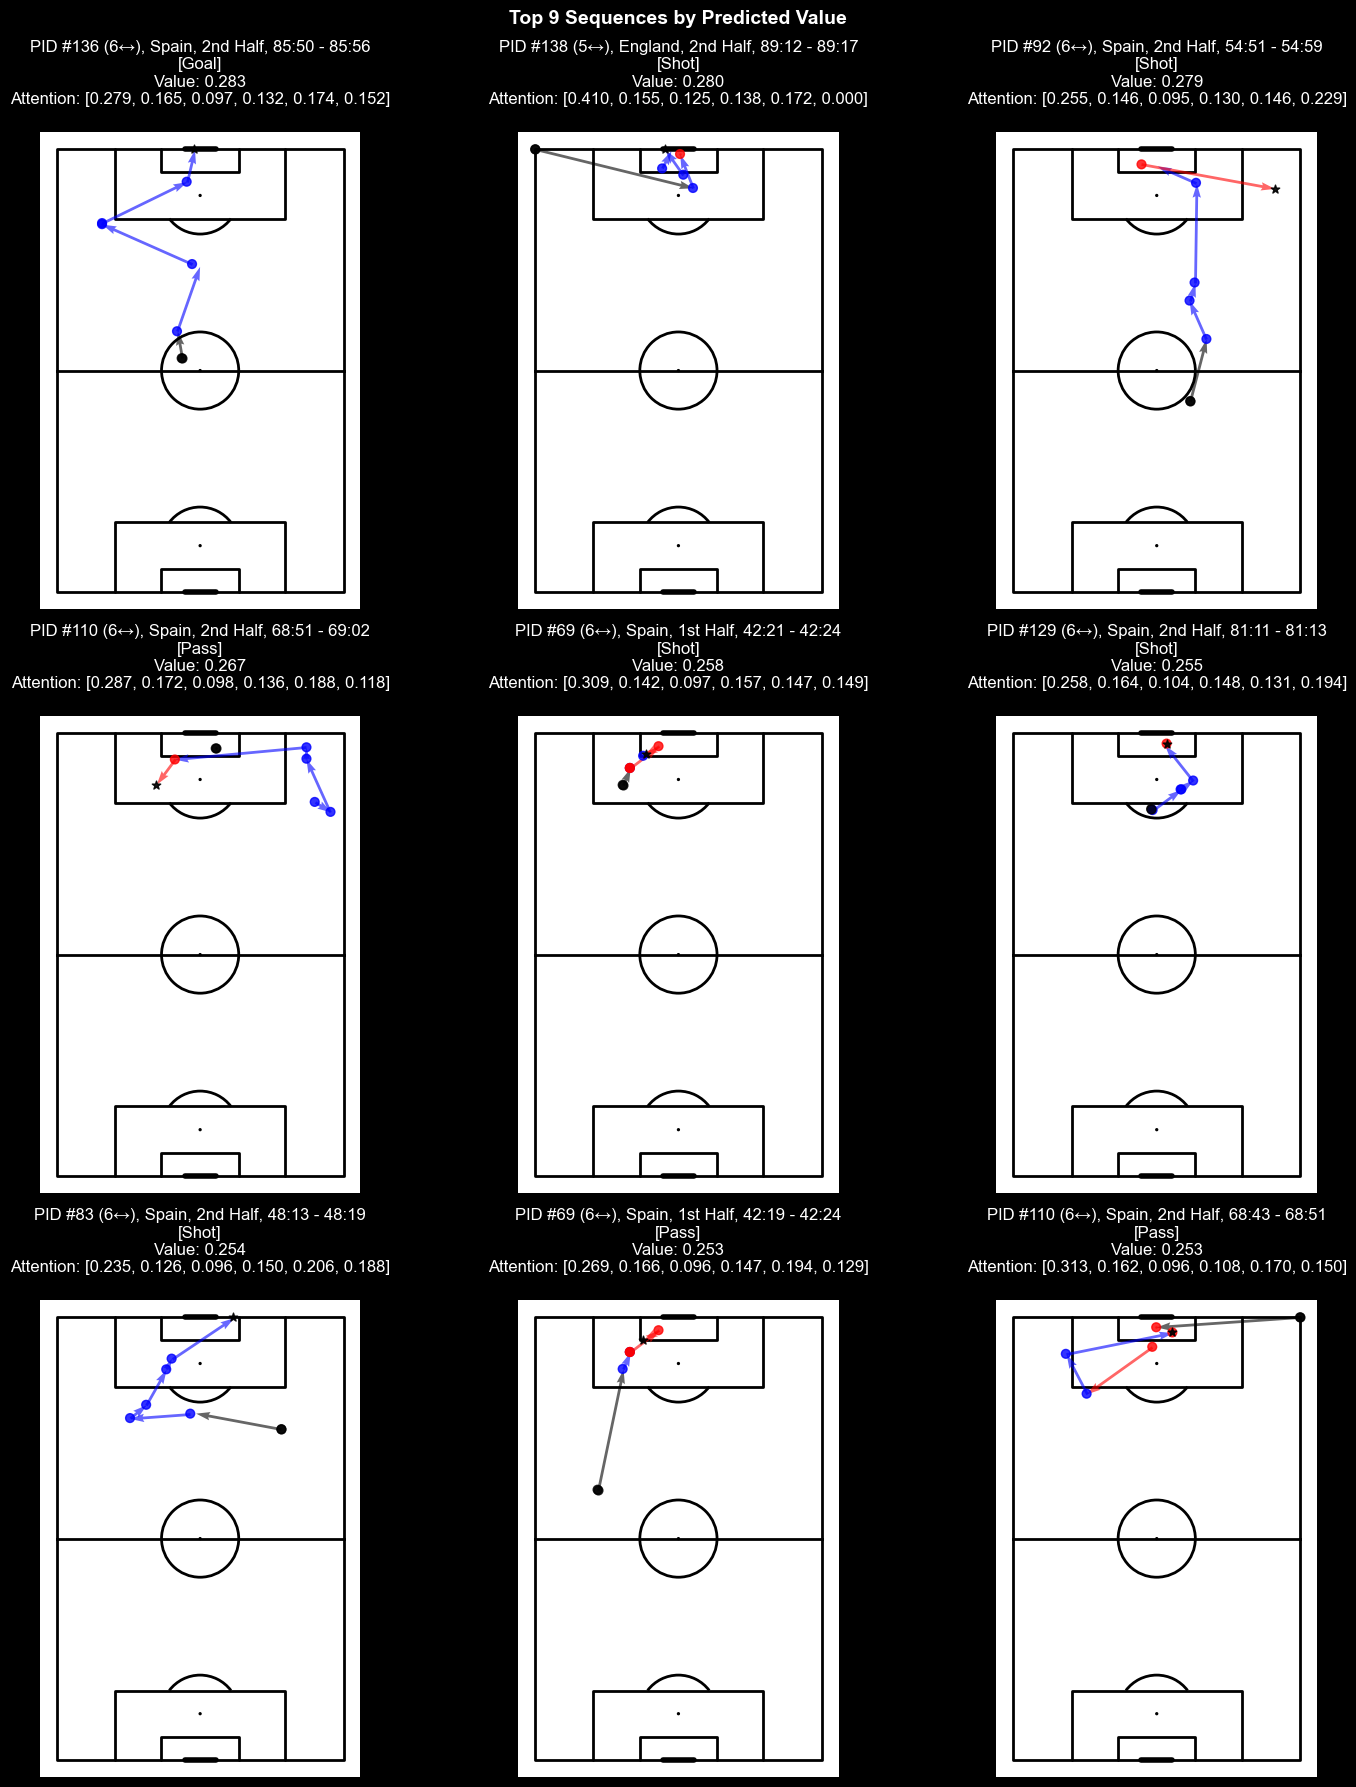

In [16]:
visualize_top_sequences(p, predicted_values, attention_weights, 9)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_final.png", dpi=300)


## 5. Additional Analysis - Padding and Masking

#### Find sequences with length less then SEQUENCE_LENGTH

In [17]:
p[0]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
0,3943043,152820f0-6ca9-4df3-943b-a67d568ff472,1,0.340,768,99174.0,52.45625,34.0425,22.18125,35.0625,0,1,5,0,England,Kobbie Mainoo,2,Pass,2.529454,False,False,0.0,768,England,0.010165,-30.2750,1.020,30.292178,3.107914,0.000,0
1,3943043,9c107df3-a3c8-4ad5-bc35-00214087a105,1,2.870,768,3468.0,22.18125,35.0625,25.06875,41.1825,21,1,0,1,England,Jordan Pickford,2,Carry,1.872089,False,False,0.0,768,England,0.010165,2.8875,6.120,6.766983,1.129951,2.530,0
2,3943043,237201b8-aef8-4823-b282-e82875795c07,1,4.742,768,3468.0,25.06875,41.1825,104.95625,10.4975,0,0,4,2,England,Jordan Pickford,2,Pass,5.137795,False,False,0.0,768,England,0.046477,79.8875,-30.685,85.577929,-0.366727,1.872,0


In [18]:
short_sequence_ids = np.array([i for i, df in enumerate(p) if len(df) < config.SEQUENCE_LENGTH])
print(f"IDs of short sequences: {short_sequence_ids}")

IDs of short sequences: [   0   81   82  159  166  204  218  270  357  363  364  365  376  440
  459  460  521  653  654  658  659  691  732  739  858  994  999 1007
 1008 1050 1051 1089 1149 1186 1222 1297 1298 1300]


#### Create X_short_sequences and p_short_sequences

In [19]:
X_short_sequences = X[short_sequence_ids]
p_short_sequences = p[short_sequence_ids]

print(f"X_short_sequences shape: {X_short_sequences.shape}")
print(f"Number of short sequences: {len(p_short_sequences)}")

X_short_sequences shape: (38, 6, 46)
Number of short sequences: 38


#### Make predictions on short sequences

In [20]:
predictions_short = model.predict(X_short_sequences, batch_size=32, verbose=0)
predicted_values_short, attention_weights_short = normalize_predictions(predictions_short)

print(f"Total short sequences analyzed: {len(predicted_values_short)}")
print(f"Sum of predicted values: {predicted_values_short.sum():.3f}")
print(f"Has attention weights: {attention_weights_short is not None}")

Total short sequences analyzed: 38
Sum of predicted values: 1.679
Has attention weights: True


#### Visualize short sequences

Processed sequence index: 35 with predicted value: 0.280
Processed sequence index: 5 with predicted value: 0.206
Processed sequence index: 19 with predicted value: 0.161
Processed sequence index: 32 with predicted value: 0.121
Processed sequence index: 30 with predicted value: 0.082
Processed sequence index: 10 with predicted value: 0.081
Processed sequence index: 1 with predicted value: 0.074
Processed sequence index: 20 with predicted value: 0.070
Processed sequence index: 31 with predicted value: 0.053


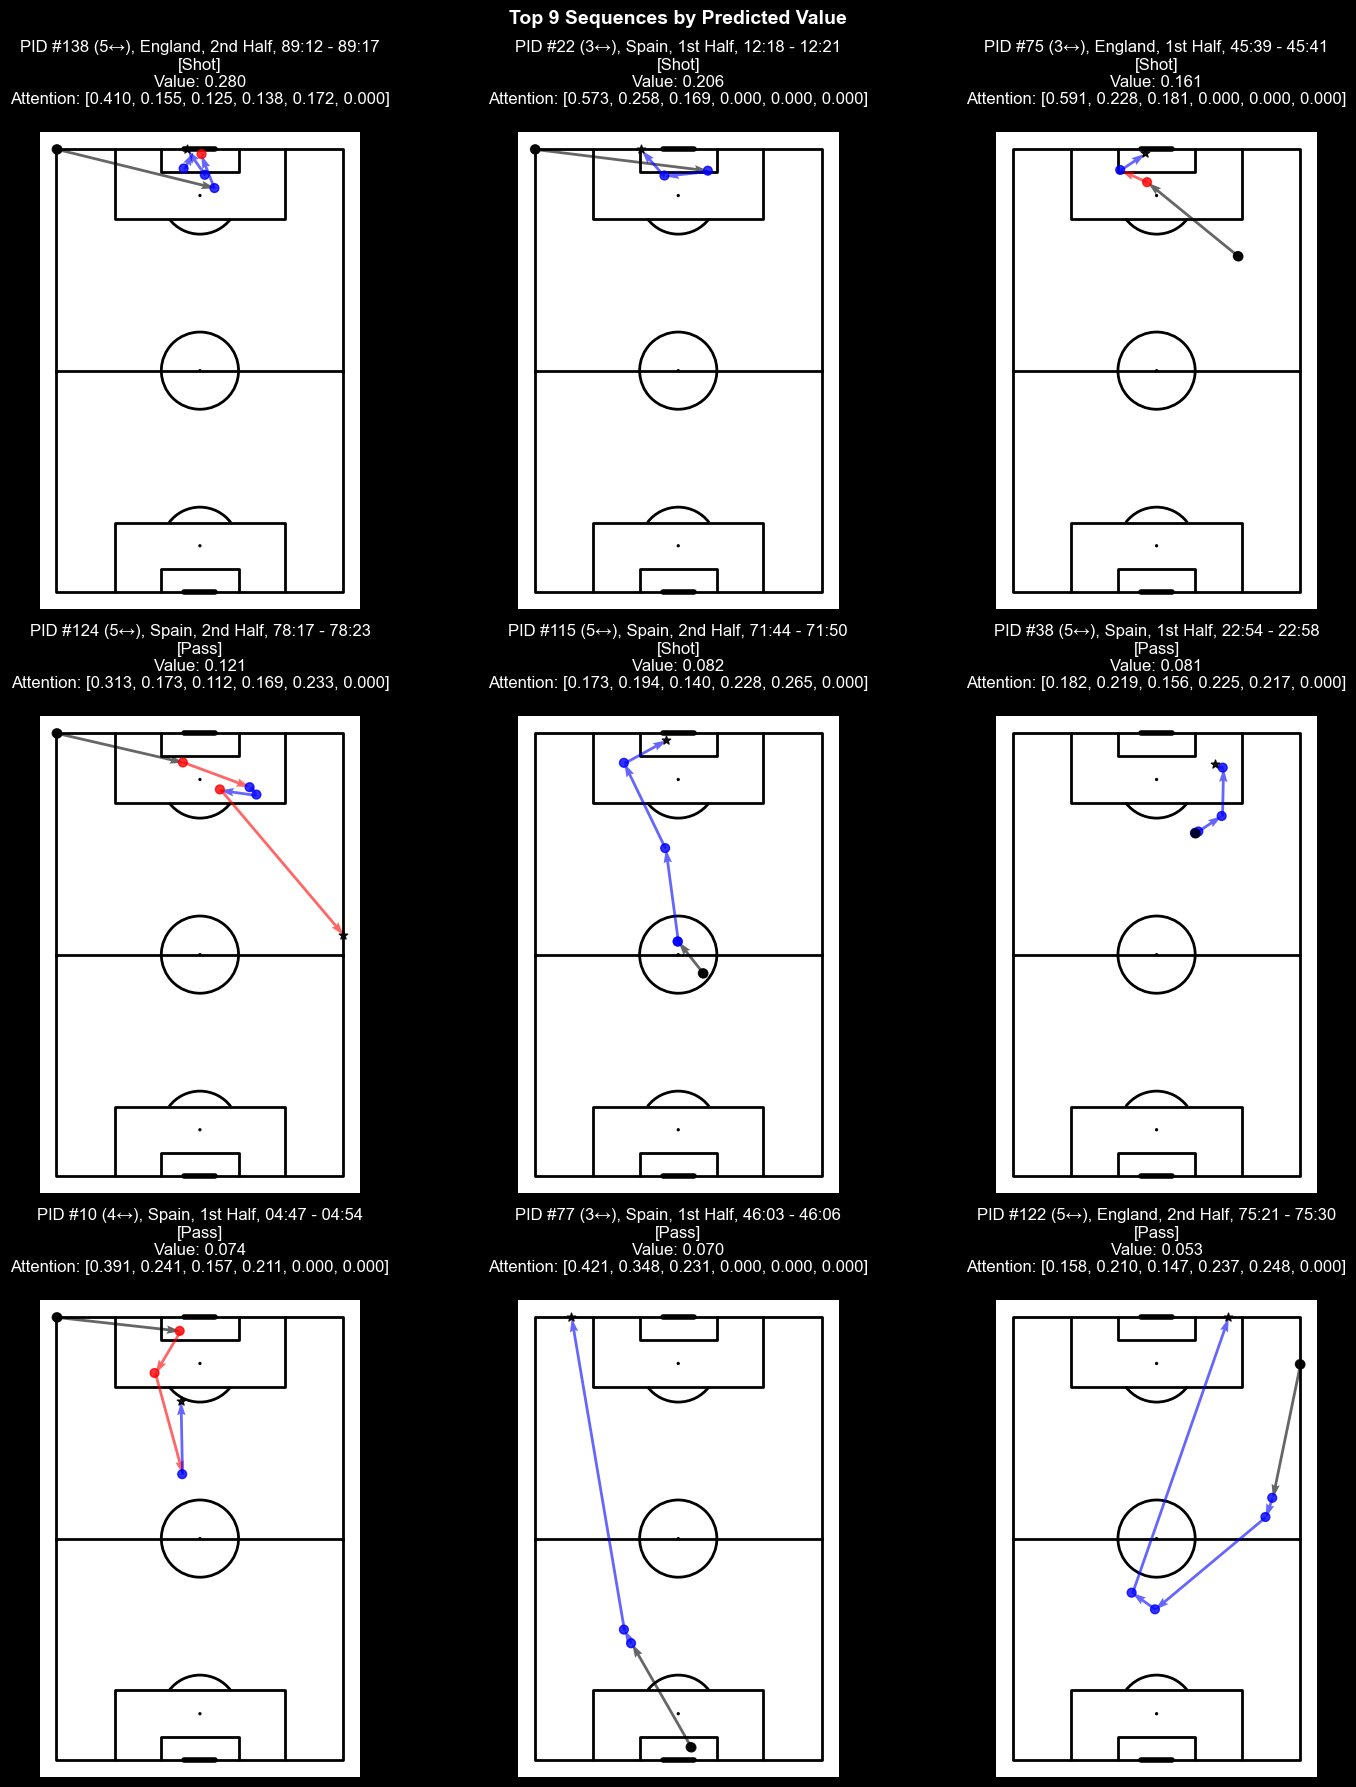

In [21]:
visualize_top_sequences(p_short_sequences, predicted_values_short, attention_weights_short, 9)
plt.savefig(f"models/{MODEL_TYPE}/top_possessions_short_sequences.png", dpi=300)


#### Get top indices from short sequences

In [22]:
top_indices_short = get_top_indices(predicted_values_short)
top_indices_short

array([35,  5, 19, 32, 30, 10,  1, 20, 31,  0, 27, 37, 21, 36, 11, 14, 16,
       22, 23, 29, 26, 25, 33,  6,  8,  4, 12,  7,  2, 24, 28, 18,  9,  3,
       15, 13, 34, 17])

Processed sequence index: 35 with predicted value: 0.280


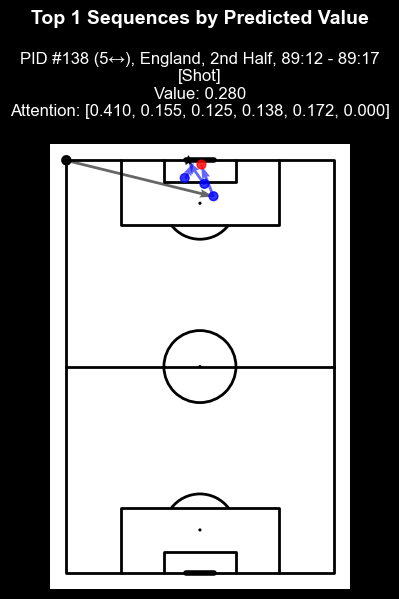

In [23]:
visualize_top_sequences(p_short_sequences, predicted_values_short, attention_weights_short, indices=np.array([35]))
None

In [24]:
p_short_sequences[35]

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,team_name,player_name,possession,type_name,duration,under_pressure,counterpress,xG,possession_team_id,possession_team_name,xT,dx,dy,distance,angle,time_diff,opposite_action
1855,3943043,5423b3d4-6ae5-4e45-ac1b-461d6085c42f,2,2652.691,768,39461.0,104.95625,67.9575,95.76875,30.5575,5,1,4,1855,England,Cole Palmer,138,Pass,1.949813,False,False,0.000000,768,England,0.037926,-9.1875,-37.400,38.511948,-1.811681,0.000,0
1856,3943043,a7918f5b-489f-4e7d-b815-a9409488f7d0,2,2654.641,768,3943.0,95.76875,30.5575,103.73125,33.7025,11,0,1,1856,England,Declan Rice,138,Shot,0.476958,False,False,0.057442,768,England,0.108051,7.9625,3.145,8.561100,0.376168,1.950,0
1857,3943043,94b975e3-7eb6-49dd-a5d0-0f7b33e24fc8,2,2655.118,772,11748.0,103.81875,33.6175,103.81875,33.6175,14,0,2,1857,Spain,Unai Simón Mendibil,138,Goal Keeper,0.000000,False,False,0.000000,768,England,0.257454,0.0000,0.000,0.000000,0.000000,0.477,1
1858,3943043,78efc835-09e5-468f-a87b-f593799568c4,2,2655.770,768,34526.0,100.40625,37.8675,104.51875,35.7425,11,0,1,1858,England,Marc Guehi,138,Shot,0.440271,True,False,0.117154,768,England,0.257454,4.1125,-2.125,4.629069,-0.476932,0.652,0
1859,3943043,e6df2aac-8a83-47c2-94a8-094c90c3e03d,2,2657.062,768,3943.0,98.91875,32.8525,104.95625,37.1025,11,0,1,1859,England,Declan Rice,138,Shot,0.695539,False,False,0.105782,768,England,0.257454,6.0375,4.250,7.383353,0.613361,1.292,0


In [25]:
X_short_sequences[35]

array([[ 0.9995833 ,  0.999375  ,  0.9120833 ,  0.449375  ,  0.36678046,
        -0.9711272 , -0.23856233,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [ 0.9120833 ,  0.449375  ,  0.98791665,  0.495625  ,  0.08153428,
         0.36735934,  0.9300791 ,  0.195     ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.     

In [26]:
attention_weights_short[35]

array([0.41032025, 0.15470801, 0.12527184, 0.13780506, 0.17189483,
       0.        ], dtype=float32)